# The Formal Definition of a Derivative

Welcome to this educational notebook on the **formal mathematical definition of derivatives**! We'll translate our intuitive understanding of gradients into precise mathematical notation.

## Learning Objectives
By the end of this notebook, you will understand:
- The formal mathematical definition of a derivative using limits
- How "rise over run" translates to the derivative formula
- The step-by-step process of differentiation using the definition
- The Sum Rule and Power Rule for derivatives
- How to apply the definition to specific functions

## Key Insight
> **The derivative is simply the limit of "rise over run" as the interval becomes infinitesimally small.**

Don't worry if this sounds intimidating - we'll build up to it step by step!

## Review: Rise Over Run for Linear Functions

Let's start by reviewing what we already know about gradients for **linear functions**.

### For a Straight Line
- **Gradient is constant** everywhere on the line
- We can pick any two points to calculate the gradient
- **Rise** = change in vertical direction (Δy)
- **Run** = change in horizontal direction (Δx)

$$\text{Gradient} = \frac{\text{Rise}}{\text{Run}} = \frac{\Delta y}{\Delta x}$$

### Examples:
- **Upward slope** → Positive gradient
- **Downward slope** → Negative gradient  
- **Horizontal line** → Zero gradient

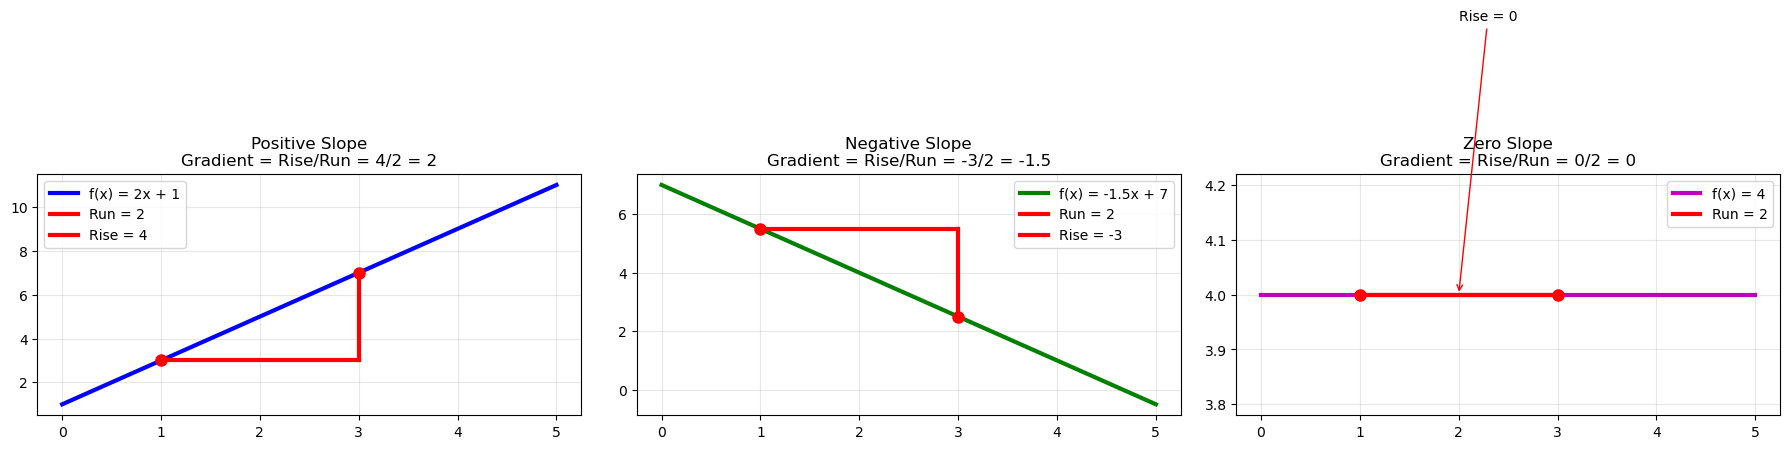

Key Points:
• For linear functions, gradient is the SAME everywhere
• Pick any two points → same rise/run ratio
• This forms the foundation for understanding derivatives


In [1]:
# Visualize rise over run for linear functions
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Example 1: Positive slope
x1 = np.linspace(0, 5, 100)
y1 = 2*x1 + 1  # slope = 2

axes[0].plot(x1, y1, 'b-', linewidth=3, label='f(x) = 2x + 1')
# Show rise over run
x_points = [1, 3]
y_points = [2*1 + 1, 2*3 + 1]  # [3, 7]
axes[0].plot(x_points, y_points, 'ro', markersize=8)
axes[0].plot([1, 3], [3, 3], 'r-', linewidth=3, label='Run = 2')
axes[0].plot([3, 3], [3, 7], 'r-', linewidth=3, label='Rise = 4')
axes[0].set_title('Positive Slope\nGradient = Rise/Run = 4/2 = 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Example 2: Negative slope  
x2 = np.linspace(0, 5, 100)
y2 = -1.5*x2 + 7  # slope = -1.5

axes[1].plot(x2, y2, 'g-', linewidth=3, label='f(x) = -1.5x + 7')
# Show rise over run
x_points = [1, 3]
y_points = [-1.5*1 + 7, -1.5*3 + 7]  # [5.5, 2.5]
axes[1].plot(x_points, y_points, 'ro', markersize=8)
axes[1].plot([1, 3], [5.5, 5.5], 'r-', linewidth=3, label='Run = 2')
axes[1].plot([3, 3], [5.5, 2.5], 'r-', linewidth=3, label='Rise = -3')
axes[1].set_title('Negative Slope\nGradient = Rise/Run = -3/2 = -1.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Example 3: Zero slope
x3 = np.linspace(0, 5, 100)
y3 = np.ones_like(x3) * 4  # slope = 0

axes[2].plot(x3, y3, 'm-', linewidth=3, label='f(x) = 4')
# Show rise over run
x_points = [1, 3]
y_points = [4, 4]
axes[2].plot(x_points, y_points, 'ro', markersize=8)
axes[2].plot([1, 3], [4, 4], 'r-', linewidth=3, label='Run = 2')
axes[2].annotate('Rise = 0', xy=(2, 4), xytext=(2, 4.5),
                arrowprops=dict(arrowstyle='->', color='red'))
axes[2].set_title('Zero Slope\nGradient = Rise/Run = 0/2 = 0')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key Points:")
print("• For linear functions, gradient is the SAME everywhere")
print("• Pick any two points → same rise/run ratio")
print("• This forms the foundation for understanding derivatives")

## The Challenge: Curved Functions

For **curved functions**, the gradient is **different at every point**! 

### The Problem
- The "rise over run" depends on which two points we choose
- We need the gradient at a **specific point**, not between two points
- How do we define gradient when the slope is constantly changing?

### The Solution
We'll use the same "rise over run" idea, but make the distance between points **infinitesimally small**.

### The Process
1. Pick a point where we want the gradient
2. Pick a second point very close to it
3. Calculate rise over run
4. Make the distance between points approach zero
5. See what value the ratio approaches

This limiting process is the **formal definition of a derivative**!

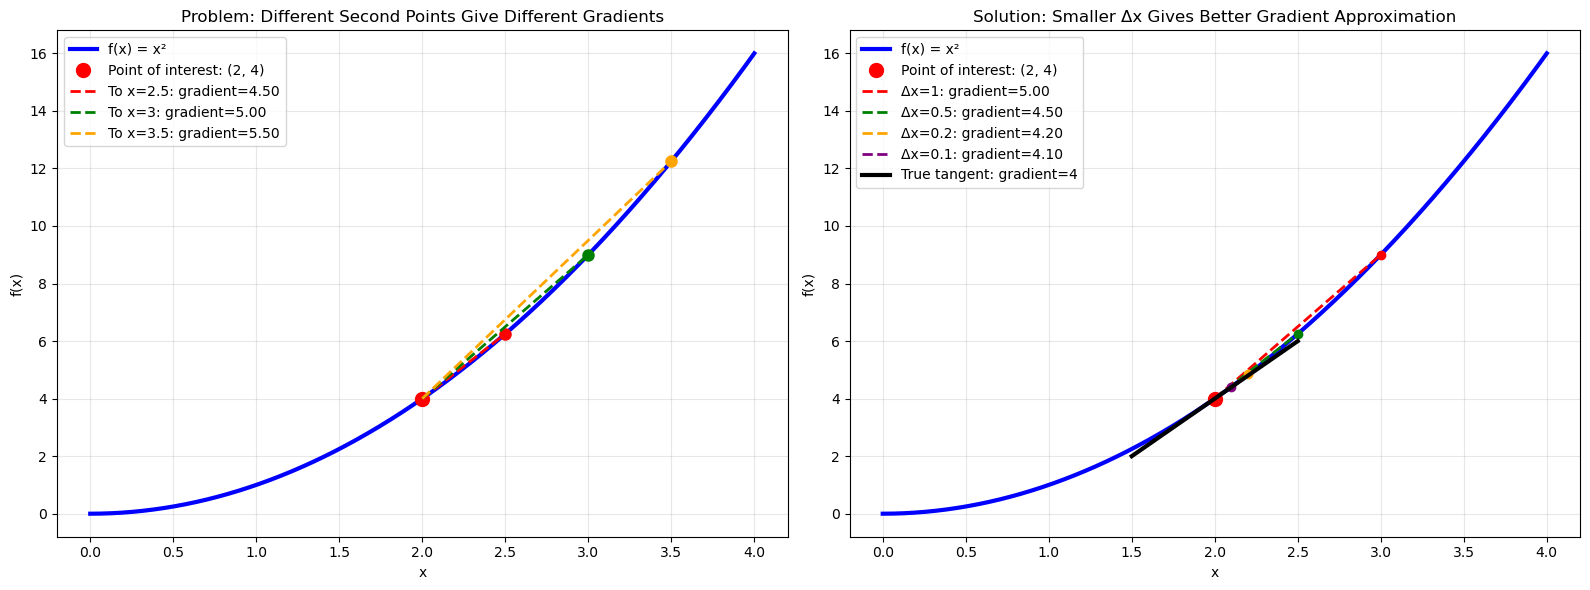

Observations:
• LEFT: Different second points → different gradient estimates
• RIGHT: Smaller Δx → gradient estimates approach the true value
• As Δx approaches 0, we get the exact gradient at the point
• This limiting process is the derivative!


In [2]:
# Demonstrate the challenge with curved functions
x = np.linspace(0, 4, 1000)
y = x**2  # A simple curved function

# Choose a specific point where we want the gradient
x_point = 2
y_point = x_point**2

# Show different "rise over run" calculations with different second points
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Show how gradient estimate depends on choice of second point
axes[0].plot(x, y, 'b-', linewidth=3, label='f(x) = x²')
axes[0].plot(x_point, y_point, 'ro', markersize=10, label=f'Point of interest: ({x_point}, {y_point})')

# Different second points
second_points = [2.5, 3, 3.5]
colors = ['red', 'green', 'orange']

for i, x2 in enumerate(second_points):
    y2 = x2**2
    
    # Calculate rise over run
    run = x2 - x_point
    rise = y2 - y_point
    gradient = rise / run
    
    # Draw the line between points
    axes[0].plot([x_point, x2], [y_point, y2], colors[i], linewidth=2, 
                linestyle='--', label=f'To x={x2}: gradient={gradient:.2f}')
    axes[0].plot(x2, y2, 'o', color=colors[i], markersize=8)

axes[0].set_title('Problem: Different Second Points Give Different Gradients')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Show how gradient estimate improves as points get closer
axes[1].plot(x, y, 'b-', linewidth=3, label='f(x) = x²')
axes[1].plot(x_point, y_point, 'ro', markersize=10, label=f'Point of interest: ({x_point}, {y_point})')

# Progressively closer second points
delta_x_values = [1, 0.5, 0.2, 0.1]
colors = ['red', 'green', 'orange', 'purple']

for i, delta_x in enumerate(delta_x_values):
    x2 = x_point + delta_x
    y2 = x2**2
    
    # Calculate rise over run
    rise = y2 - y_point
    gradient = rise / delta_x
    
    # Draw the line between points
    axes[1].plot([x_point, x2], [y_point, y2], colors[i], linewidth=2,
                linestyle='--', label=f'Δx={delta_x}: gradient={gradient:.2f}')
    axes[1].plot(x2, y2, 'o', color=colors[i], markersize=6)

# The true tangent line (we know the derivative of x² is 2x, so at x=2, derivative=4)
true_slope = 4  # 2 * x_point
x_tangent = np.linspace(1.5, 2.5, 100)
y_tangent = y_point + true_slope * (x_tangent - x_point)
axes[1].plot(x_tangent, y_tangent, 'k-', linewidth=3, label=f'True tangent: gradient={true_slope}')

axes[1].set_title('Solution: Smaller Δx Gives Better Gradient Approximation')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observations:")
print("• LEFT: Different second points → different gradient estimates")
print("• RIGHT: Smaller Δx → gradient estimates approach the true value")
print("• As Δx approaches 0, we get the exact gradient at the point")
print("• This limiting process is the derivative!")

## The Formal Definition of a Derivative

Now let's translate our intuitive understanding into precise mathematical notation.

### Setting Up the Problem

1. **Choose a point**: $x$ (where we want the gradient)
2. **Choose a nearby point**: $x + \Delta x$ (where $\Delta x$ is a small change)
3. **Find the function values**:
   - At first point: $f(x)$
   - At second point: $f(x + \Delta x)$

### The Rise Over Run Formula

$$\text{Approximate Gradient} = \frac{\text{Rise}}{\text{Run}} = \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

### The Limiting Process

As $\Delta x$ gets smaller and smaller, this ratio approaches the **exact gradient** at point $x$.

### **The Formal Definition**

$$f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

### Alternative Notation
- $f'(x)$ (read as "f prime of x")
- $\frac{df}{dx}$ (read as "d f, d x")

### Key Points
- We're **not** setting $\Delta x = 0$ (that would be division by zero!)
- We're finding what the ratio **approaches** as $\Delta x$ gets arbitrarily close to zero
- This limiting process captures the instantaneous rate of change

## Example 1: Differentiating a Linear Function

Let's apply our formal definition to a simple case we understand: **$f(x) = 3x + 2$**

We know the answer should be $3$ (the coefficient of $x$), but let's verify using the definition.

### Step-by-Step Application

**Step 1**: Write the definition
$$f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

**Step 2**: Substitute our function
$$f'(x) = \lim_{\Delta x \to 0} \frac{[3(x + \Delta x) + 2] - [3x + 2]}{\Delta x}$$

**Step 3**: Expand and simplify
$$f'(x) = \lim_{\Delta x \to 0} \frac{3x + 3\Delta x + 2 - 3x - 2}{\Delta x}$$

**Step 4**: Cancel terms
$$f'(x) = \lim_{\Delta x \to 0} \frac{3\Delta x}{\Delta x}$$

**Step 5**: Simplify the fraction  
$$f'(x) = \lim_{\Delta x \to 0} 3$$

**Step 6**: Evaluate the limit
$$f'(x) = 3$$

✅ **Result**: The derivative is $3$, as expected!

Differentiation of f(x) = 3x + 2 using the formal definition
At x = 2:

Δx =   2.00 | f(x+Δx) =  14.00 | f(x) =   8.00 | Ratio =   3.00
Δx =   1.00 | f(x+Δx) =  11.00 | f(x) =   8.00 | Ratio =   3.00
Δx =   0.50 | f(x+Δx) =   9.50 | f(x) =   8.00 | Ratio =   3.00
Δx =   0.10 | f(x+Δx) =   8.30 | f(x) =   8.00 | Ratio =   3.00
Δx =   0.01 | f(x+Δx) =   8.03 | f(x) =   8.00 | Ratio =   3.00

As Δx approaches 0, the ratio approaches 3.00
Therefore, f'(x) = 3 for all x


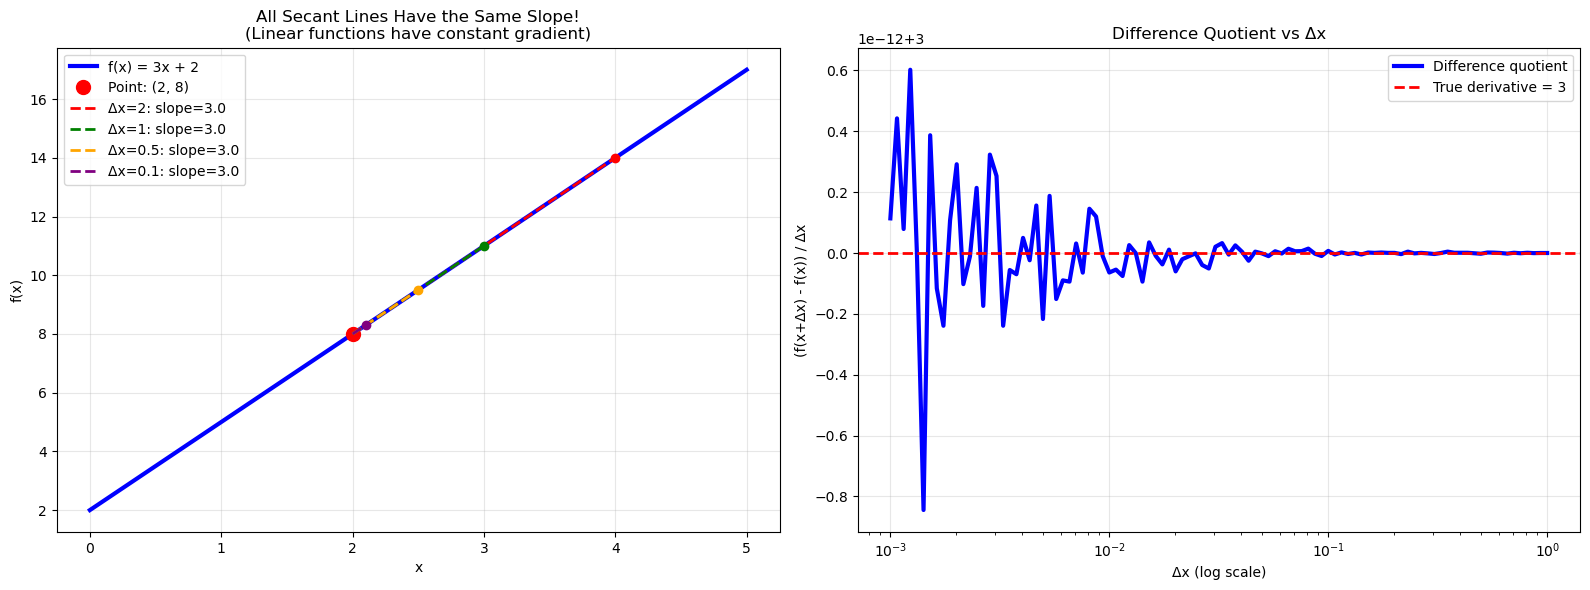


Key Insights:
• For linear functions, ALL secant lines have the same slope
• The difference quotient is constant regardless of Δx
• This confirms our algebraic calculation: f'(x) = 3


In [3]:
# Visualize the differentiation of a linear function
def f_linear(x):
    return 3*x + 2

# Show the step-by-step calculation
x_val = 2  # Choose a specific point
delta_x_values = [2, 1, 0.5, 0.1, 0.01]

print("Differentiation of f(x) = 3x + 2 using the formal definition")
print("="*60)
print("At x = 2:")
print()

for i, delta_x in enumerate(delta_x_values):
    # Calculate f(x + Δx) - f(x) / Δx
    f_x = f_linear(x_val)
    f_x_plus_delta = f_linear(x_val + delta_x)
    
    difference_quotient = (f_x_plus_delta - f_x) / delta_x
    
    print(f"Δx = {delta_x:6.2f} | f(x+Δx) = {f_x_plus_delta:6.2f} | f(x) = {f_x:6.2f} | Ratio = {difference_quotient:6.2f}")

print()
print("As Δx approaches 0, the ratio approaches 3.00")
print("Therefore, f'(x) = 3 for all x")

# Visualize the process
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Show the function and secant lines
x = np.linspace(0, 5, 100)
y = f_linear(x)

axes[0].plot(x, y, 'b-', linewidth=3, label='f(x) = 3x + 2')
axes[0].plot(x_val, f_linear(x_val), 'ro', markersize=10, label=f'Point: ({x_val}, {f_linear(x_val)})')

# Show secant lines for different Δx values
colors = ['red', 'green', 'orange', 'purple']
for i, delta_x in enumerate(delta_x_values[:4]):  # Show first 4
    x2 = x_val + delta_x
    y2 = f_linear(x2)
    
    # Draw secant line
    x_line = np.array([x_val, x2])
    y_line = np.array([f_linear(x_val), y2])
    axes[0].plot(x_line, y_line, colors[i], linewidth=2, linestyle='--',
                label=f'Δx={delta_x}: slope={3:.1f}')
    axes[0].plot(x2, y2, 'o', color=colors[i], markersize=6)

axes[0].set_title('All Secant Lines Have the Same Slope!\n(Linear functions have constant gradient)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Show how the difference quotient converges
delta_x_fine = np.logspace(-3, 0, 100)  # From 0.001 to 1
ratios = []

for delta_x in delta_x_fine:
    ratio = (f_linear(x_val + delta_x) - f_linear(x_val)) / delta_x
    ratios.append(ratio)

axes[1].semilogx(delta_x_fine, ratios, 'b-', linewidth=3, label='Difference quotient')
axes[1].axhline(y=3, color='red', linestyle='--', linewidth=2, label='True derivative = 3')
axes[1].set_title('Difference Quotient vs Δx')
axes[1].set_xlabel('Δx (log scale)')
axes[1].set_ylabel('(f(x+Δx) - f(x)) / Δx')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("• For linear functions, ALL secant lines have the same slope")
print("• The difference quotient is constant regardless of Δx")
print("• This confirms our algebraic calculation: f'(x) = 3")

## The Sum Rule: A Powerful Insight

Notice something important in our previous example: we differentiated $f(x) = 3x + 2$, which has **two parts**.

### What Happened
We could have treated this as:
- **Part 1**: $3x$ → derivative = $3$
- **Part 2**: $+2$ → derivative = $0$ (constants have zero derivative)
- **Combined**: $3 + 0 = 3$

### The Sum Rule
> **If $f(x) = g(x) + h(x)$, then $f'(x) = g'(x) + h'(x)$**

In other words: **The derivative of a sum is the sum of the derivatives.**

### Why This Works
The limit operation distributes over addition:
$$\lim_{\Delta x \to 0} \frac{[g(x + \Delta x) + h(x + \Delta x)] - [g(x) + h(x)]}{\Delta x}$$

$$= \lim_{\Delta x \to 0} \frac{g(x + \Delta x) - g(x)}{\Delta x} + \lim_{\Delta x \to 0} \frac{h(x + \Delta x) - h(x)}{\Delta x}$$

$$= g'(x) + h'(x)$$

### Practical Benefit
Instead of differentiating complex expressions all at once, we can:
1. Break them into simpler parts
2. Differentiate each part separately  
3. Add the results together

## Example 2: Differentiating a Quadratic Function

Now let's tackle something more interesting: **$f(x) = 5x^2$**

This is a curved function, so the algebra will be more involved, but the process is identical.

### Step-by-Step Application

**Step 1**: Write the definition
$$f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

**Step 2**: Substitute our function
$$f'(x) = \lim_{\Delta x \to 0} \frac{5(x + \Delta x)^2 - 5x^2}{\Delta x}$$

**Step 3**: Expand $(x + \Delta x)^2$
Remember: $(x + \Delta x)^2 = x^2 + 2x\Delta x + (\Delta x)^2$

$$f'(x) = \lim_{\Delta x \to 0} \frac{5(x^2 + 2x\Delta x + (\Delta x)^2) - 5x^2}{\Delta x}$$

**Step 4**: Distribute and simplify
$$f'(x) = \lim_{\Delta x \to 0} \frac{5x^2 + 10x\Delta x + 5(\Delta x)^2 - 5x^2}{\Delta x}$$

**Step 5**: Cancel the $5x^2$ terms
$$f'(x) = \lim_{\Delta x \to 0} \frac{10x\Delta x + 5(\Delta x)^2}{\Delta x}$$

**Step 6**: Factor out $\Delta x$
$$f'(x) = \lim_{\Delta x \to 0} \frac{\Delta x(10x + 5\Delta x)}{\Delta x}$$

**Step 7**: Cancel $\Delta x$
$$f'(x) = \lim_{\Delta x \to 0} (10x + 5\Delta x)$$

**Step 8**: Take the limit
As $\Delta x \to 0$, the term $5\Delta x \to 0$

$$f'(x) = 10x$$

✅ **Result**: The derivative is $10x$!

Differentiation of f(x) = 5x² using the formal definition
At x = 1.5:

Δx =  1.000 | Difference quotient =   20.000 | Error =    5.000
Δx =  0.500 | Difference quotient =   17.500 | Error =    2.500
Δx =  0.100 | Difference quotient =   15.500 | Error =    0.500
Δx =  0.010 | Difference quotient =   15.050 | Error =    0.050
Δx =  0.001 | Difference quotient =   15.005 | Error =    0.005

True derivative at x = 1.5: f'(1.5) = 10 × 1.5 = 15.0


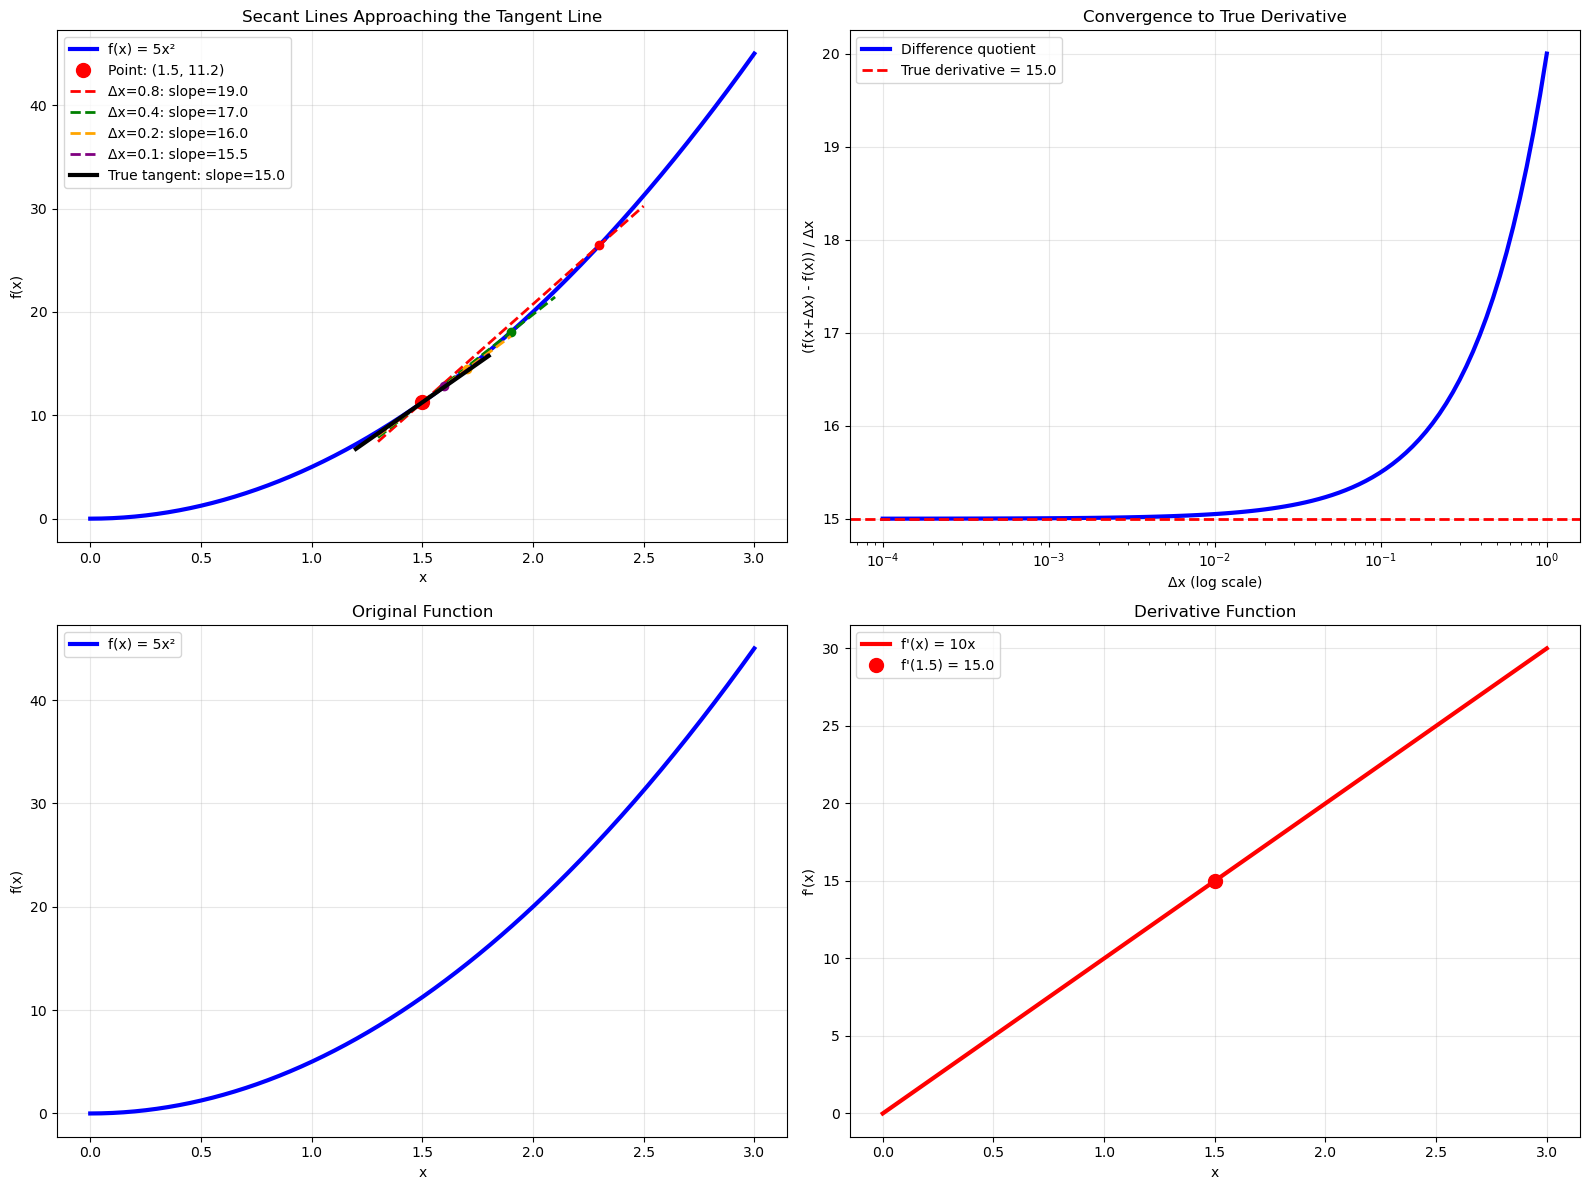


Key Insights:
• The derivative of 5x² is 10x (not constant like linear functions!)
• At different x values, the derivative has different values
• The secant lines converge to the tangent line as Δx → 0
• This process works for any smooth function


In [4]:
# Visualize the differentiation of f(x) = 5x²

def f_quadratic(x):
    return 5 * x**2

def f_quadratic_derivative(x):
    return 10 * x  # We calculated this: derivative of 5x² is 10x

# Demonstrate the limiting process numerically
x_val = 1.5  # Choose a specific point
delta_x_values = [1, 0.5, 0.1, 0.01, 0.001]

print("Differentiation of f(x) = 5x² using the formal definition")
print("="*65)
print(f"At x = {x_val}:")
print()

true_derivative = f_quadratic_derivative(x_val)

for delta_x in delta_x_values:
    # Calculate the difference quotient
    f_x = f_quadratic(x_val)
    f_x_plus_delta = f_quadratic(x_val + delta_x)
    
    difference_quotient = (f_x_plus_delta - f_x) / delta_x
    error = abs(difference_quotient - true_derivative)
    
    print(f"Δx = {delta_x:6.3f} | Difference quotient = {difference_quotient:8.3f} | Error = {error:8.3f}")

print(f"\nTrue derivative at x = {x_val}: f'({x_val}) = 10 × {x_val} = {true_derivative}")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top left: Function and secant lines
x = np.linspace(0, 3, 300)
y = f_quadratic(x)

axes[0,0].plot(x, y, 'b-', linewidth=3, label='f(x) = 5x²')
axes[0,0].plot(x_val, f_quadratic(x_val), 'ro', markersize=10, 
               label=f'Point: ({x_val}, {f_quadratic(x_val):.1f})')

# Show secant lines approaching the tangent
colors = ['red', 'green', 'orange', 'purple']
for i, delta_x in enumerate([0.8, 0.4, 0.2, 0.1]):
    x2 = x_val + delta_x
    y2 = f_quadratic(x2)
    
    # Calculate slope
    slope = (y2 - f_quadratic(x_val)) / delta_x
    
    # Draw secant line
    x_line = np.linspace(x_val - 0.2, x2 + 0.2, 100)
    y_line = f_quadratic(x_val) + slope * (x_line - x_val)
    
    axes[0,0].plot(x_line, y_line, colors[i], linewidth=2, linestyle='--',
                   label=f'Δx={delta_x}: slope={slope:.1f}')
    axes[0,0].plot(x2, y2, 'o', color=colors[i], markersize=6)

# True tangent line
x_tangent = np.linspace(x_val - 0.3, x_val + 0.3, 100)
y_tangent = f_quadratic(x_val) + true_derivative * (x_tangent - x_val)
axes[0,0].plot(x_tangent, y_tangent, 'k-', linewidth=3, 
               label=f'True tangent: slope={true_derivative:.1f}')

axes[0,0].set_title('Secant Lines Approaching the Tangent Line')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('f(x)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Top right: Convergence of difference quotient
delta_x_fine = np.logspace(-4, 0, 100)
ratios = []

for delta_x in delta_x_fine:
    ratio = (f_quadratic(x_val + delta_x) - f_quadratic(x_val)) / delta_x
    ratios.append(ratio)

axes[0,1].semilogx(delta_x_fine, ratios, 'b-', linewidth=3, label='Difference quotient')
axes[0,1].axhline(y=true_derivative, color='red', linestyle='--', linewidth=2, 
                  label=f'True derivative = {true_derivative}')
axes[0,1].set_title('Convergence to True Derivative')
axes[0,1].set_xlabel('Δx (log scale)')
axes[0,1].set_ylabel('(f(x+Δx) - f(x)) / Δx')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Bottom left: Original function
x_full = np.linspace(0, 3, 300)
y_full = f_quadratic(x_full)
axes[1,0].plot(x_full, y_full, 'b-', linewidth=3, label='f(x) = 5x²')
axes[1,0].set_title('Original Function')
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('f(x)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Bottom right: Derivative function
y_derivative = f_quadratic_derivative(x_full)
axes[1,1].plot(x_full, y_derivative, 'r-', linewidth=3, label="f'(x) = 10x")
axes[1,1].plot(x_val, true_derivative, 'ro', markersize=10, 
               label=f"f'({x_val}) = {true_derivative}")
axes[1,1].set_title('Derivative Function')
axes[1,1].set_xlabel('x')
axes[1,1].set_ylabel("f'(x)")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print("• The derivative of 5x² is 10x (not constant like linear functions!)")
print("• At different x values, the derivative has different values")
print("• The secant lines converge to the tangent line as Δx → 0")
print("• This process works for any smooth function")

## The Power Rule: A General Pattern

From our quadratic example, we can discover a powerful general rule!

### What We Observed
- $f(x) = 5x^2$ → $f'(x) = 10x = 5 \cdot 2 \cdot x^{2-1}$

### The Pattern
For functions of the form $f(x) = ax^b$:

$$f'(x) = abx^{b-1}$$

### The Power Rule
> **If $f(x) = ax^n$, then $f'(x) = anx^{n-1}$**

### How It Works
1. **Multiply by the power**: The exponent becomes a coefficient
2. **Multiply by the original coefficient**: Keep any constants
3. **Reduce the power by 1**: The new exponent is $n-1$

### Examples
| Function | Derivative | Using Power Rule |
|----------|------------|------------------|
| $x^3$ | $3x^2$ | $3 \cdot x^{3-1} = 3x^2$ |
| $4x^5$ | $20x^4$ | $4 \cdot 5 \cdot x^{5-1} = 20x^4$ |
| $x^2$ | $2x$ | $2 \cdot x^{2-1} = 2x$ |
| $7x$ | $7$ | $7 \cdot 1 \cdot x^{1-1} = 7x^0 = 7$ |
| $x$ | $1$ | $1 \cdot x^{1-1} = x^0 = 1$ |
| $5$ | $0$ | $5 = 5x^0 \rightarrow 5 \cdot 0 \cdot x^{-1} = 0$ |

### Why This Works
The power rule emerges naturally from applying the formal definition to $f(x) = ax^n$ and using the binomial theorem to expand $(x + \Delta x)^n$.

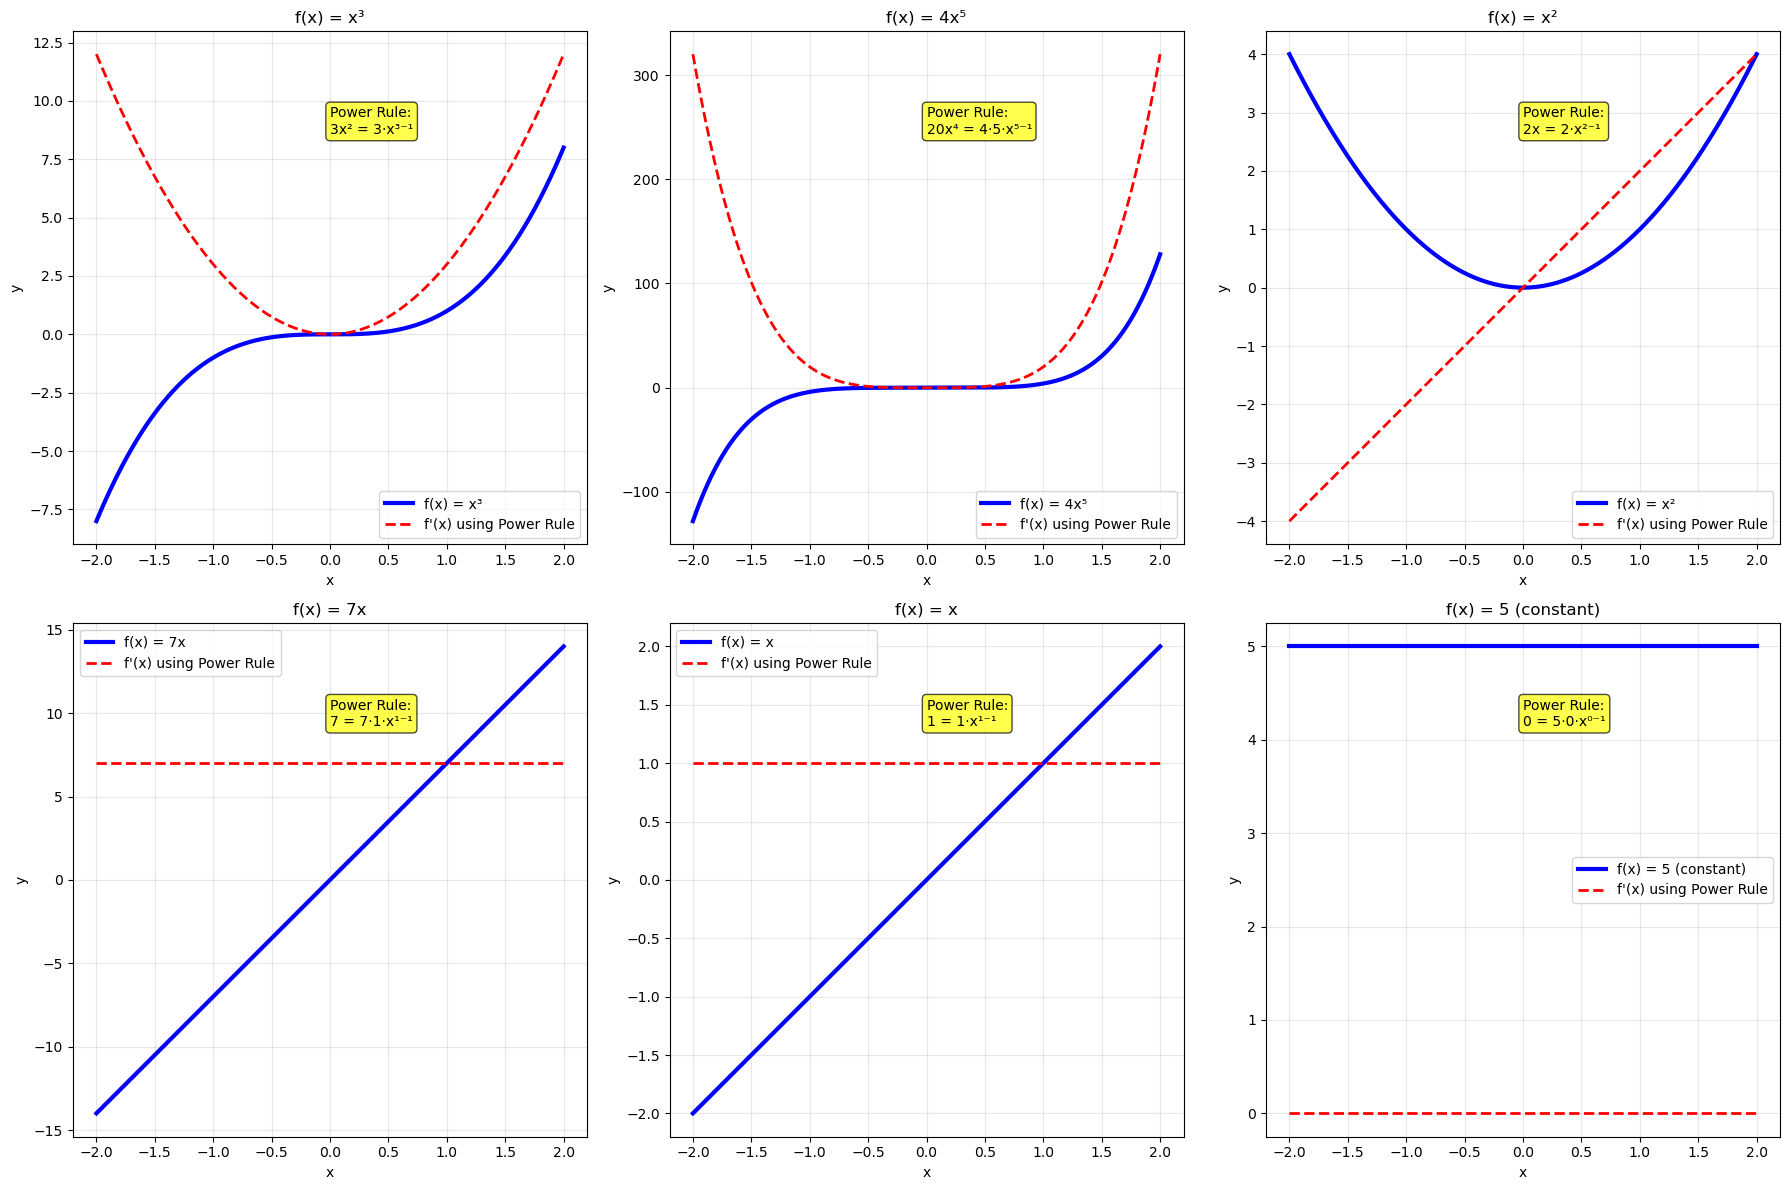

Verification: Power Rule vs Numerical Differentiation
f(x) = x³           | Power Rule:   6.7500 | Numerical:   6.7500 | Error: 2.56e-08
f(x) = 4x⁵          | Power Rule: 101.2500 | Numerical: 101.2500 | Error: 7.39e-07
f(x) = x²           | Power Rule:   3.0000 | Numerical:   3.0000 | Error: 1.82e-08
f(x) = 7x           | Power Rule:   7.0000 | Numerical:   7.0000 | Error: 1.31e-07
f(x) = x            | Power Rule:   1.0000 | Numerical:   1.0000 | Error: 6.08e-09

The Power Rule gives exact results (errors are due to numerical precision)!

INTERACTIVE EXAMPLE: Differentiate a polynomial


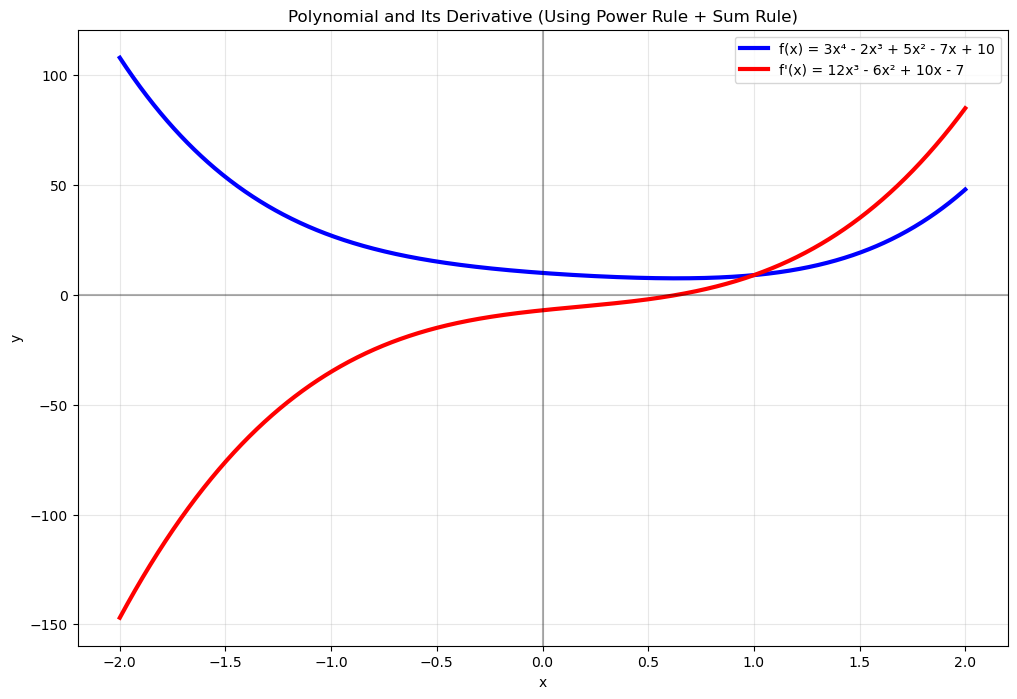

Differentiation using Power Rule + Sum Rule:
f(x) = 3x⁴ - 2x³ + 5x² - 7x + 10
f'(x) = 3·4x³ - 2·3x² + 5·2x - 7·1 + 0
f'(x) = 12x³ - 6x² + 10x - 7

This would be very tedious using the formal definition directly!


In [6]:
# Demonstrate the Power Rule with multiple examples

# Define functions and their derivatives using the power rule
functions = {
    'x³': lambda x: x**3,
    '4x⁵': lambda x: 4 * x**5, 
    'x²': lambda x: x**2,
    '7x': lambda x: 7 * x,
    'x': lambda x: x,
    '5 (constant)': lambda x: 5 * np.ones_like(x)
}

derivatives = {
    'x³': lambda x: 3 * x**2,
    '4x⁵': lambda x: 20 * x**4,
    'x²': lambda x: 2 * x,
    '7x': lambda x: 7 * np.ones_like(x),
    'x': lambda x: np.ones_like(x),
    '5 (constant)': lambda x: np.zeros_like(x)
}

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

x = np.linspace(-2, 2, 1000)
x_pos = np.linspace(0.1, 2, 1000)  # For functions that need positive x

function_names = list(functions.keys())

for i, name in enumerate(function_names):
    if '⁵' in name or '³' in name:
        # Use full range for odd powers
        x_plot = x
    else:
        # Use positive range for even powers to avoid negative values in some cases
        x_plot = x if name != '4x⁵' else x
    
    # Plot original function
    y = functions[name](x_plot)
    axes[i].plot(x_plot, y, 'b-', linewidth=3, label=f'f(x) = {name}')
    
    # Plot derivative
    y_deriv = derivatives[name](x_plot)
    axes[i].plot(x_plot, y_deriv, 'r--', linewidth=2, label=f"f'(x) using Power Rule")
    
    axes[i].set_title(f'f(x) = {name}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')
    
    # Add annotation showing the power rule application
    if name == 'x³':
        axes[i].text(0.5, 0.8, "Power Rule:\n3x² = 3·x³⁻¹", transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    elif name == '4x⁵':
        axes[i].text(0.5, 0.8, "Power Rule:\n20x⁴ = 4·5·x⁵⁻¹", transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    elif name == 'x²':
        axes[i].text(0.5, 0.8, "Power Rule:\n2x = 2·x²⁻¹", transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    elif name == '7x':
        axes[i].text(0.5, 0.8, "Power Rule:\n7 = 7·1·x¹⁻¹", transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    elif name == 'x':
        axes[i].text(0.5, 0.8, "Power Rule:\n1 = 1·x¹⁻¹", transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
    elif name == '5 (constant)':
        axes[i].text(0.5, 0.8, "Power Rule:\n0 = 5·0·x⁰⁻¹", transform=axes[i].transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

# Verify the power rule by comparing with numerical differentiation
def numerical_derivative(f, x, h=1e-8):
    """Calculate numerical derivative using the formal definition"""
    return (f(x + h) - f(x)) / h

print("Verification: Power Rule vs Numerical Differentiation")
print("="*60)

test_point = 1.5
for name in function_names:
    if 'constant' not in name:  # Skip constant for this test
        # Analytical derivative using power rule
        analytical = derivatives[name](test_point)
        
        # Numerical derivative using formal definition
        numerical = numerical_derivative(functions[name], test_point)
        
        # Handle scalar vs array returns
        if np.isscalar(analytical):
            analytical_val = analytical
        else:
            analytical_val = analytical.item() if hasattr(analytical, 'item') else float(analytical)
            
        error = abs(analytical_val - numerical)
        
        print(f"f(x) = {name:12} | Power Rule: {analytical_val:8.4f} | Numerical: {numerical:8.4f} | Error: {error:.2e}")

print("\nThe Power Rule gives exact results (errors are due to numerical precision)!")

# Interactive example: Build a polynomial and differentiate it
print("\n" + "="*60)
print("INTERACTIVE EXAMPLE: Differentiate a polynomial")
print("="*60)

# Example polynomial: f(x) = 3x⁴ - 2x³ + 5x² - 7x + 10
def polynomial(x):
    return 3*x**4 - 2*x**3 + 5*x**2 - 7*x + 10

def polynomial_derivative(x):
    # Using power rule term by term (Sum Rule!)
    # 3x⁴ → 12x³
    # -2x³ → -6x²  
    # 5x² → 10x
    # -7x → -7
    # 10 → 0
    return 12*x**3 - 6*x**2 + 10*x - 7

x_demo = np.linspace(-2, 2, 1000)
y_demo = polynomial(x_demo)
y_deriv_demo = polynomial_derivative(x_demo)

plt.figure(figsize=(12, 8))
plt.plot(x_demo, y_demo, 'b-', linewidth=3, label='f(x) = 3x⁴ - 2x³ + 5x² - 7x + 10')
plt.plot(x_demo, y_deriv_demo, 'r-', linewidth=3, label="f'(x) = 12x³ - 6x² + 10x - 7")
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
plt.title('Polynomial and Its Derivative (Using Power Rule + Sum Rule)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Differentiation using Power Rule + Sum Rule:")
print("f(x) = 3x⁴ - 2x³ + 5x² - 7x + 10")
print("f'(x) = 3·4x³ - 2·3x² + 5·2x - 7·1 + 0")
print("f'(x) = 12x³ - 6x² + 10x - 7")
print("\nThis would be very tedious using the formal definition directly!")

## Key Takeaways: Your Calculus Toolbox

### What We've Accomplished

✅ **Formal Definition**: $f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$

✅ **Sum Rule**: $(f + g)' = f' + g'$ (derivative of sum = sum of derivatives)

✅ **Power Rule**: $(ax^n)' = anx^{n-1}$ (multiply by power, reduce power by 1)

✅ **Practical Application**: Can differentiate any polynomial quickly!

### The Big Picture

Instead of applying the formal definition every time (which gets tedious), we now have **rules** that make differentiation much faster:

1. **Break complex functions into simpler parts** (Sum Rule)
2. **Apply Power Rule to each term**
3. **Add the results together**

### From Tedious to Efficient

**Before (using definition)**: 
- Set up limit expression
- Expand algebra carefully  
- Simplify and take limit
- ⏰ Time: Several minutes per function

**Now (using rules)**:
- Identify terms and powers
- Apply Power Rule to each term
- ⏰ Time: Seconds!

### What's Next?

The lecture mentioned there are more rules coming, and some "magical special case functions" that differentiate in interesting ways. These tools will expand your calculus toolbox even further!

### Practice Mindset

> "Differentiation is simply substituting the function into the formal expression."

But with rules, it becomes: **"Differentiation is pattern recognition and rule application."**

## Practice Exercises: Test Your Understanding

Try these problems to solidify your understanding of the formal definition and differentiation rules:

### Exercise 1: Using the Formal Definition
Apply the formal definition to find the derivative of $f(x) = x^2 + 3x$

**Steps to follow**:
1. Write out $f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$
2. Substitute the function
3. Expand and simplify
4. Take the limit

### Exercise 2: Power Rule Practice
Find the derivatives of these functions using the Power Rule:

a) $f(x) = x^4$
b) $g(x) = 6x^3$  
c) $h(x) = -2x^5$
d) $j(x) = x$
e) $k(x) = 8$

### Exercise 3: Sum Rule + Power Rule
Differentiate these polynomials:

a) $f(x) = x^3 + 2x^2 - 5x + 7$
b) $g(x) = 4x^5 - 3x^4 + x^2 - 6$
c) $h(x) = -x^4 + 8x^3 - 12x + 15$

### Exercise 4: Conceptual Understanding
Answer these questions:

a) Why can't we just set $\Delta x = 0$ in the formal definition?
b) What does the limit $\lim_{\Delta x \to 0}$ represent physically?
c) How does the Power Rule relate to the formal definition?
d) Why is the Sum Rule useful in practice?

In [ ]:
# Solutions to Practice Exercises

print("SOLUTIONS TO PRACTICE EXERCISES")
print("="*50)

print("\nExercise 1: Using the Formal Definition for f(x) = x² + 3x")
print("-" * 55)
print("Step 1: f'(x) = lim[Δx→0] [f(x+Δx) - f(x)] / Δx")
print("Step 2: f'(x) = lim[Δx→0] [(x+Δx)² + 3(x+Δx) - (x² + 3x)] / Δx")
print("Step 3: f'(x) = lim[Δx→0] [x² + 2xΔx + (Δx)² + 3x + 3Δx - x² - 3x] / Δx")
print("Step 4: f'(x) = lim[Δx→0] [2xΔx + (Δx)² + 3Δx] / Δx")
print("Step 5: f'(x) = lim[Δx→0] [Δx(2x + Δx + 3)] / Δx")
print("Step 6: f'(x) = lim[Δx→0] [2x + Δx + 3]")
print("Step 7: f'(x) = 2x + 3")

print("\n" + "="*50)

print("\nExercise 2: Power Rule Practice")
print("-" * 30)
print("a) f(x) = x⁴        → f'(x) = 4x³")
print("b) g(x) = 6x³       → g'(x) = 6·3x² = 18x²")  
print("c) h(x) = -2x⁵      → h'(x) = -2·5x⁴ = -10x⁴")
print("d) j(x) = x         → j'(x) = 1·x⁰ = 1")
print("e) k(x) = 8         → k'(x) = 0 (constant)")

print("\n" + "="*50)

print("\nExercise 3: Sum Rule + Power Rule")
print("-" * 35)
print("a) f(x) = x³ + 2x² - 5x + 7")
print("   f'(x) = 3x² + 4x - 5 + 0 = 3x² + 4x - 5")
print()
print("b) g(x) = 4x⁵ - 3x⁴ + x² - 6")  
print("   g'(x) = 20x⁴ - 12x³ + 2x - 0 = 20x⁴ - 12x³ + 2x")
print()
print("c) h(x) = -x⁴ + 8x³ - 12x + 15")
print("   h'(x) = -4x³ + 24x² - 12 + 0 = -4x³ + 24x² - 12")

print("\n" + "="*50)

print("\nExercise 4: Conceptual Understanding")
print("-" * 35)
print("a) Why can't we set Δx = 0?")
print("   → Division by zero is undefined! We need the LIMIT as Δx approaches 0.")
print()
print("b) What does lim[Δx→0] represent physically?")
print("   → The instantaneous rate of change at a single point.")
print("   → It's what happens when the time interval becomes infinitesimally small.")
print()
print("c) How does the Power Rule relate to the formal definition?")
print("   → The Power Rule is derived by applying the formal definition to f(x) = axⁿ")
print("   → It saves us from doing the algebra every time!")
print()
print("d) Why is the Sum Rule useful?")
print("   → Lets us differentiate complex functions piece by piece")
print("   → Break down complicated expressions into simpler parts")

# Verify some solutions numerically
print("\n" + "="*50)
print("\nNumerical Verification of Our Solutions")
print("-" * 40)

def verify_derivative(f, f_prime, x_val, name):
    """Verify analytical derivative against numerical approximation"""
    h = 1e-8
    numerical = (f(x_val + h) - f(x_val)) / h
    analytical = f_prime(x_val)
    error = abs(numerical - analytical)
    print(f"{name:20} | Analytical: {analytical:8.4f} | Numerical: {numerical:8.4f} | Error: {error:.2e}")

# Test functions from exercises
x_test = 1.5

# Exercise 1: f(x) = x² + 3x, f'(x) = 2x + 3
f1 = lambda x: x**2 + 3*x
f1_prime = lambda x: 2*x + 3
verify_derivative(f1, f1_prime, x_test, "x² + 3x")

# Exercise 3a: f(x) = x³ + 2x² - 5x + 7, f'(x) = 3x² + 4x - 5  
f3a = lambda x: x**3 + 2*x**2 - 5*x + 7
f3a_prime = lambda x: 3*x**2 + 4*x - 5
verify_derivative(f3a, f3a_prime, x_test, "x³ + 2x² - 5x + 7")

# Exercise 3b: f(x) = 4x⁵ - 3x⁴ + x² - 6, f'(x) = 20x⁴ - 12x³ + 2x
f3b = lambda x: 4*x**5 - 3*x**4 + x**2 - 6  
f3b_prime = lambda x: 20*x**4 - 12*x**3 + 2*x
verify_derivative(f3b, f3b_prime, x_test, "4x⁵ - 3x⁴ + x² - 6")

print("\nPerfect! Our analytical solutions match numerical calculations.")
print("This confirms that our Power Rule and Sum Rule applications are correct!")

# Create a visual summary
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.linspace(-2, 2, 1000)

# Exercise 1 function
y1 = x**2 + 3*x
y1_prime = 2*x + 3
axes[0].plot(x, y1, 'b-', linewidth=3, label='f(x) = x² + 3x')
axes[0].plot(x, y1_prime, 'r--', linewidth=2, label="f'(x) = 2x + 3")
axes[0].set_title('Exercise 1: Using Formal Definition')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exercise 3a function  
y3a = x**3 + 2*x**2 - 5*x + 7
y3a_prime = 3*x**2 + 4*x - 5
axes[1].plot(x, y3a, 'b-', linewidth=3, label='f(x) = x³ + 2x² - 5x + 7')
axes[1].plot(x, y3a_prime, 'r--', linewidth=2, label="f'(x) = 3x² + 4x - 5")
axes[1].set_title('Exercise 3a: Power + Sum Rules')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Exercise 3c function
y3c = -x**4 + 8*x**3 - 12*x + 15  
y3c_prime = -4*x**3 + 24*x**2 - 12
axes[2].plot(x, y3c, 'b-', linewidth=3, label='f(x) = -x⁴ + 8x³ - 12x + 15')
axes[2].plot(x, y3c_prime, 'r--', linewidth=2, label="f'(x) = -4x³ + 24x² - 12")
axes[2].set_title('Exercise 3c: Complex Polynomial')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

print("\nCongratulations! You now understand:")
print("• The formal definition of derivatives")
print("• How to apply the definition step-by-step")  
print("• The Power Rule and Sum Rule")
print("• How these rules make differentiation much more efficient")
print("\nYou're ready for more advanced differentiation techniques!")